# Scratch baselines without SAM — CustomCNN, ResNet18, ViT
- Same preprocessing, cosine+warmup schedule, early stopping on AUROC.
- Final metrics shown at 0.5 and at a *recall‑first* operating point (screening).


In [11]:
# Clean imports + path setup
import sys, time, warnings
from pathlib import Path
try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning)

# Resolve project root (directory containing `src/`)
proj_root = Path.cwd()
for _ in range(5):
    if (proj_root / "src").exists(): break
    proj_root = proj_root.parent
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))
print("proj_root:", proj_root)

# Project imports
from src import (
    DataCfg, TrainCfg, build_dataloaders, get_device, set_seed,
    build_custom_cnn, build_resnet18, build_vit_scratch,
    train_model, evaluate, choose_threshold_by_min_recall,
    summarize_at_threshold, plot_curve, plot_two_series, diag_plots,
    add_result, result_registry
)

import numpy as np, torch
set_seed(42)
DEVICE = get_device()
DEVICE


proj_root: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project


device(type='mps')

In [7]:
# === Paths/config ===
DATASET_DIR = Path("../Data/chest_xray")  # <--- EDIT THIS IF NEEDED

# Keep split identical across notebooks for fair comparison
data_cfg = DataCfg(
    dataset_dir=DATASET_DIR,
    image_size=224,
    batch_size=32,
    num_workers=0,          # 0 on macOS avoids "MallocStackLogging" noise
    pin_memory=True,
    use_stratified_val=True,
    val_ratio=0.20,         # use the same val split you used elsewhere
    gray_to_rgb=False,      # <<< 1-CHANNEL grayscale
    compute_norm_stats=True,# <<< compute mean/std for 1 channel from train set
    balance_sampler=True
)

train_loader, val_loader, test_loader, info = build_dataloaders(data_cfg, device=DEVICE)
print("Classes:", info["classes"])
print("Lens:", info["n_train"], info["n_val"], info["n_test"])
print("Train counts:", info["train_counts"])

# Class weights: when balance_sampler=True, set None to avoid double-correction
class_weights = None

# Sanity check: confirm 1-channel
xb, yb = next(iter(train_loader))
print("Batch shape:", tuple(xb.shape))  # expect (B, 1, 224, 224)
del xb, yb


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4185 1047 624
Train counts: [1079, 3106]
Batch shape: (32, 1, 224, 224)


In [3]:
# Shared training cfg "envelope" for scratch runs with SAM OFF
scratch_no_sam = TrainCfg(
    epochs=100, patience=15, monitor="va_auroc",
    base_lr=3e-4, weight_decay=0.3,   # <- ViT defaults; CNN/ResNet override below
    clip_grad_norm=1.0, use_amp=False,
    use_sam=False, sam_rho=0.0,       # SAM OFF
    use_cosine=True, warmup_epochs=3, min_lr_mult=0.01,
    target_recall=0.95,
    llrd=False, head_lr_mult=1.0
)


[CustomCNN-scratch-1ch] epoch 01/100  tr_loss=0.4778  val_loss=0.5483  val_acc=0.7841  val_f1=0.8311  val_auroc=0.9402  (no_improve=0)
[CustomCNN-scratch-1ch] epoch 02/100  tr_loss=0.4655  val_loss=0.3706  val_acc=0.7937  val_f1=0.8770  val_auroc=0.9278  (no_improve=1)
[CustomCNN-scratch-1ch] epoch 03/100  tr_loss=0.4505  val_loss=0.4457  val_acc=0.8204  val_f1=0.8665  val_auroc=0.9178  (no_improve=2)
[CustomCNN-scratch-1ch] epoch 04/100  tr_loss=0.4022  val_loss=0.3352  val_acc=0.8109  val_f1=0.8841  val_auroc=0.9327  (no_improve=3)
[CustomCNN-scratch-1ch] epoch 05/100  tr_loss=0.4132  val_loss=0.2925  val_acc=0.8825  val_f1=0.9163  val_auroc=0.9475  (no_improve=0)
[CustomCNN-scratch-1ch] epoch 06/100  tr_loss=0.3859  val_loss=0.2861  val_acc=0.8863  val_f1=0.9194  val_auroc=0.9401  (no_improve=1)
[CustomCNN-scratch-1ch] epoch 07/100  tr_loss=0.3749  val_loss=0.2660  val_acc=0.8835  val_f1=0.9219  val_auroc=0.9441  (no_improve=2)
[CustomCNN-scratch-1ch] epoch 08/100  tr_loss=0.3721  v

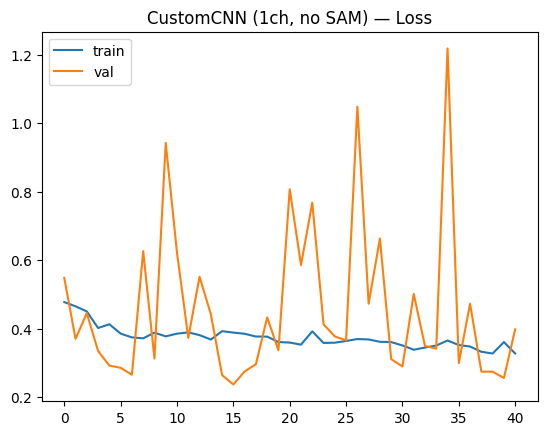

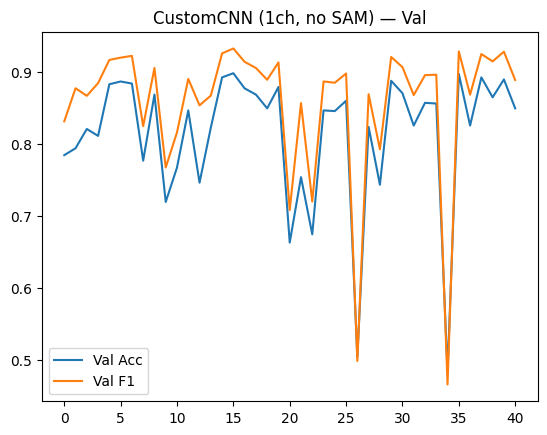

[CustomCNN-1ch @0.5] {'acc': 0.8526, 'precision': 0.888, 'recall': 0.8744, 'f1': 0.8811, 'auroc': 0.9198, 'thr': 0.5}
[CustomCNN-1ch @Rec] {'acc': 0.8413, 'precision': 0.8129, 'recall': 0.9692, 'f1': 0.8842, 'auroc': 0.9198, 'thr': 0.3135}


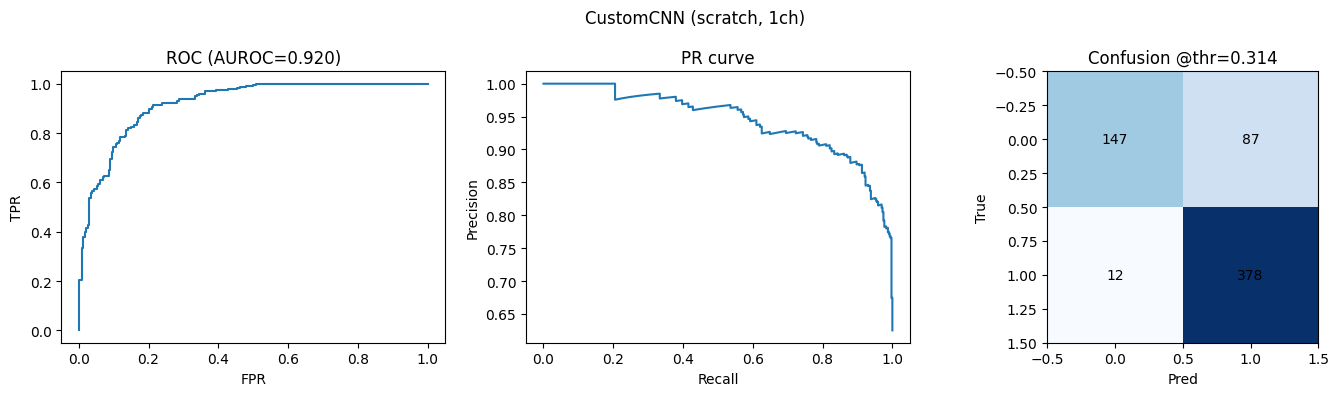

{'summary@0.5': {'acc': 0.8525641025641025,
  'precision': 0.8880208333333334,
  'recall': 0.8743589743589744,
  'f1': 0.8811369509043928,
  'auroc': 0.9198444006136313,
  'thr': 0.5},
 'summary@recall': {'acc': 0.8413461538461539,
  'precision': 0.8129032258064516,
  'recall': 0.9692307692307692,
  'f1': 0.8842105263157894,
  'auroc': 0.9198444006136313,
  'thr': 0.3135},
 'threshold': 0.3135,
 'time_sec': 3448.64901304245,
 'params': 481122}

In [4]:
cfg = scratch_no_sam

cnn = build_custom_cnn(in_chans=1, num_classes=2, width=32, dropout=0.0)  # <<< in_chans=1
t0 = time.time()
cnn_tr, cnn_hist, cnn_time = train_model(
    cnn, train_loader, val_loader, DEVICE, arch="custom_cnn",
    epochs=cfg.epochs, base_lr=0.1, weight_decay=1e-3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.0,
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="CustomCNN-scratch-1ch"
)
cnn_time = time.time() - t0

plot_curve(cnn_hist['tr_loss'], cnn_hist['va_loss'], "CustomCNN (1ch, no SAM) — Loss")
plot_two_series(cnn_hist['va_acc'], "Val Acc", cnn_hist['va_f1'], "Val F1", "CustomCNN (1ch, no SAM) — Val")

va = evaluate(cnn_tr, val_loader, DEVICE)
thr, *_ = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(cnn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[CustomCNN-1ch @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[CustomCNN-1ch @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("CustomCNN (scratch, 1ch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("CustomCNN (scratch, 1ch)", cnn_tr, sum_05, sum_reca, threshold=thr, time_sec=cnn_time)


[ResNet18-scratch-1ch] epoch 01/90  tr_loss=0.4808  val_loss=0.2812  val_acc=0.8787  val_f1=0.9127  val_auroc=0.9686  (no_improve=0)
[ResNet18-scratch-1ch] epoch 02/90  tr_loss=0.5744  val_loss=0.9565  val_acc=0.7689  val_f1=0.8167  val_auroc=0.9644  (no_improve=1)
[ResNet18-scratch-1ch] epoch 03/90  tr_loss=0.5956  val_loss=0.3739  val_acc=0.8711  val_f1=0.9086  val_auroc=0.9423  (no_improve=2)
[ResNet18-scratch-1ch] epoch 04/90  tr_loss=0.4599  val_loss=0.2608  val_acc=0.8816  val_f1=0.9193  val_auroc=0.9456  (no_improve=3)
[ResNet18-scratch-1ch] epoch 05/90  tr_loss=0.4066  val_loss=0.2201  val_acc=0.8940  val_f1=0.9244  val_auroc=0.9743  (no_improve=0)
[ResNet18-scratch-1ch] epoch 06/90  tr_loss=0.3578  val_loss=0.2000  val_acc=0.9083  val_f1=0.9385  val_auroc=0.9672  (no_improve=1)
[ResNet18-scratch-1ch] epoch 07/90  tr_loss=0.3427  val_loss=0.2695  val_acc=0.8653  val_f1=0.9022  val_auroc=0.9704  (no_improve=2)
[ResNet18-scratch-1ch] epoch 08/90  tr_loss=0.3502  val_loss=0.2124  

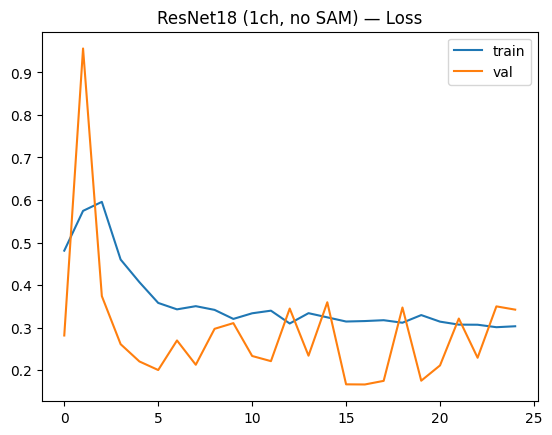

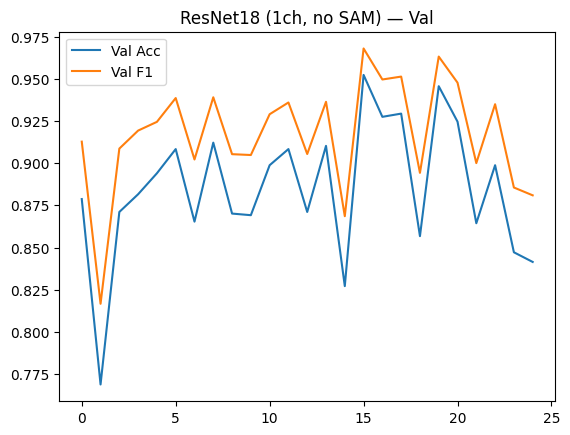

[ResNet18-1ch @0.5] {'acc': 0.8494, 'precision': 0.8957, 'recall': 0.859, 'f1': 0.877, 'auroc': 0.9171, 'thr': 0.5}
[ResNet18-1ch @Rec] {'acc': 0.7997, 'precision': 0.7645, 'recall': 0.9821, 'f1': 0.8597, 'auroc': 0.9171, 'thr': 0.111}


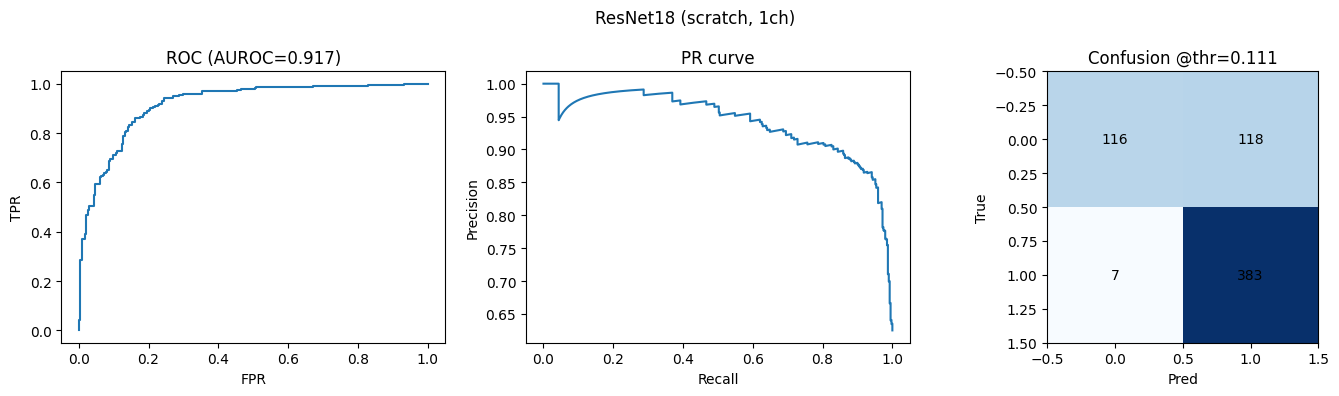

{'summary@0.5': {'acc': 0.8493589743589743,
  'precision': 0.8957219251336899,
  'recall': 0.8589743589743589,
  'f1': 0.8769633507853403,
  'auroc': 0.9171159325005478,
  'thr': 0.5},
 'summary@recall': {'acc': 0.7996794871794872,
  'precision': 0.7644710578842315,
  'recall': 0.982051282051282,
  'f1': 0.8597081930415263,
  'auroc': 0.9171159325005478,
  'thr': 0.111},
 'threshold': 0.111,
 'time_sec': 1464.1912660598755,
 'params': 11171266}

In [5]:
rn = build_resnet18(in_chans=1, num_classes=2, pretrained=False, conv_stem=False)  # <<< in_chans=1
t0 = time.time()
rn_tr, rn_hist, rn_time = train_model(
    rn, train_loader, val_loader, DEVICE, arch="resnet18",
    epochs=90, base_lr=0.1, weight_decay=1e-3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.0,
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=10, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="ResNet18-scratch-1ch"
)
rn_time = time.time() - t0

plot_curve(rn_hist['tr_loss'], rn_hist['va_loss'], "ResNet18 (1ch, no SAM) — Loss")
plot_two_series(rn_hist['va_acc'], "Val Acc", rn_hist['va_f1'], "Val F1", "ResNet18 (1ch, no SAM) — Val")

va = evaluate(rn_tr, val_loader, DEVICE)
thr, *_ = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(rn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ResNet18-1ch @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ResNet18-1ch @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ResNet18 (scratch, 1ch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ResNet18 (scratch, 1ch)", rn_tr, sum_05, sum_reca, threshold=thr, time_sec=rn_time)


[ViT-scratch-1ch] epoch 01/120  tr_loss=0.5906  val_loss=0.3279  val_acc=0.8672  val_f1=0.9049  val_auroc=0.9524  (no_improve=0)
[ViT-scratch-1ch] epoch 02/120  tr_loss=0.5201  val_loss=0.7180  val_acc=0.7125  val_f1=0.7647  val_auroc=0.8856  (no_improve=1)
[ViT-scratch-1ch] epoch 03/120  tr_loss=0.4857  val_loss=0.4475  val_acc=0.8090  val_f1=0.8534  val_auroc=0.9719  (no_improve=0)
[ViT-scratch-1ch] epoch 04/120  tr_loss=0.5043  val_loss=0.3097  val_acc=0.8797  val_f1=0.9139  val_auroc=0.9550  (no_improve=1)
[ViT-scratch-1ch] epoch 05/120  tr_loss=0.4648  val_loss=0.3552  val_acc=0.8443  val_f1=0.8846  val_auroc=0.9469  (no_improve=2)
[ViT-scratch-1ch] epoch 06/120  tr_loss=0.4495  val_loss=0.2285  val_acc=0.9102  val_f1=0.9390  val_auroc=0.9627  (no_improve=3)
[ViT-scratch-1ch] epoch 07/120  tr_loss=0.4123  val_loss=0.3103  val_acc=0.8863  val_f1=0.9192  val_auroc=0.9555  (no_improve=4)
[ViT-scratch-1ch] epoch 08/120  tr_loss=0.4342  val_loss=0.4607  val_acc=0.7679  val_f1=0.8152  v

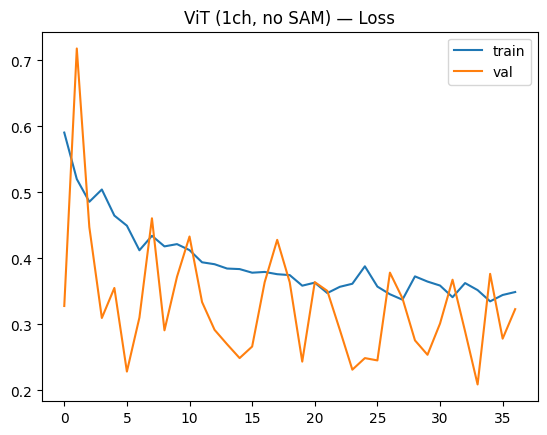

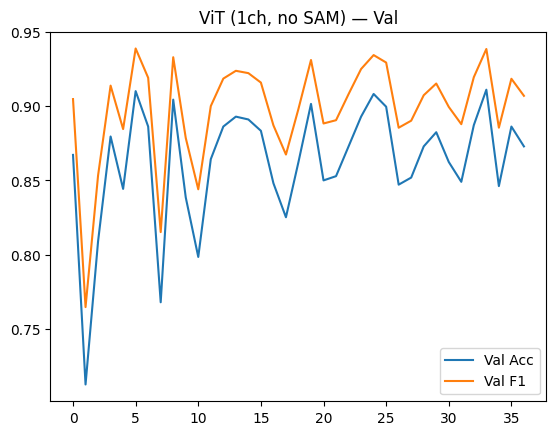

[ViT-1ch @0.5] {'acc': 0.8446, 'precision': 0.9036, 'recall': 0.841, 'f1': 0.8712, 'auroc': 0.9181, 'thr': 0.5}
[ViT-1ch @Rec] {'acc': 0.8077, 'precision': 0.7801, 'recall': 0.9641, 'f1': 0.8624, 'auroc': 0.9181, 'thr': 0.1475}


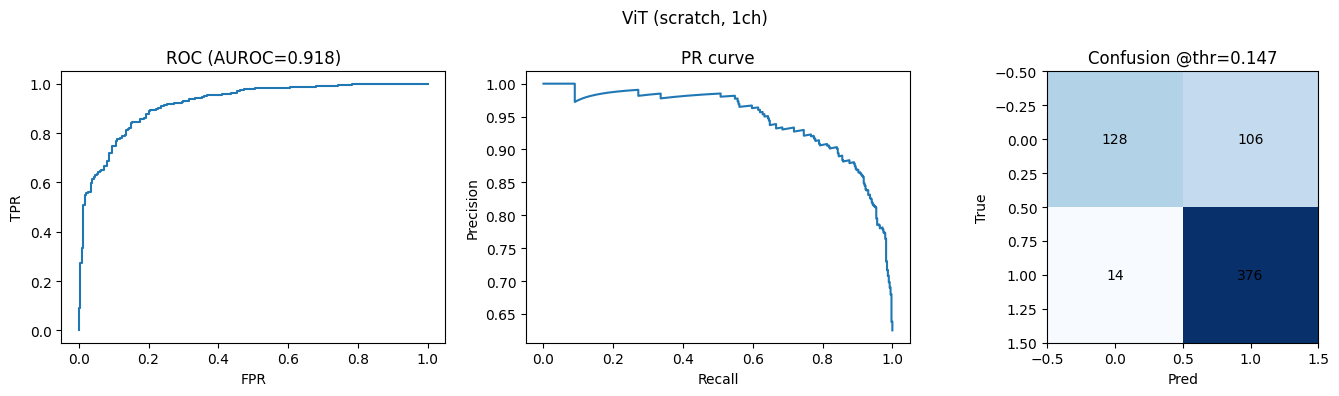

{'summary@0.5': {'acc': 0.844551282051282,
  'precision': 0.9035812672176309,
  'recall': 0.841025641025641,
  'f1': 0.8711819389110226,
  'auroc': 0.9180911680911681,
  'thr': 0.5},
 'summary@recall': {'acc': 0.8076923076923077,
  'precision': 0.7800829875518672,
  'recall': 0.9641025641025641,
  'f1': 0.8623853211009175,
  'auroc': 0.9180911680911681,
  'thr': 0.1475},
 'threshold': 0.1475,
 'time_sec': 3795.443729877472,
 'params': 21469826}

In [9]:
vit = build_vit_scratch(
    img_size=224, in_chans=1, num_classes=2,   # <<< in_chans=1
    embed_dim=384, depth=12, heads=6, patch=16, mlp_ratio=4.0, drop=0.1
)
t0 = time.time()
vit_tr, vit_hist, vit_time = train_model(
    vit, train_loader, val_loader, DEVICE, arch="vit",
    epochs=120, base_lr=3e-4, weight_decay=0.3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.0,
    use_cosine=True, warmup_epochs=5, min_lr_mult=0.01,
    monitor="va_auroc", patience=15, clip_grad_norm=1.0,
    class_weights=class_weights, llrd=False, head_lr_mult=1.0, use_amp=False,
    tag="ViT-scratch-1ch"
)
vit_time = time.time() - t0

plot_curve(vit_hist['tr_loss'], vit_hist['va_loss'], "ViT (1ch, no SAM) — Loss")
plot_two_series(vit_hist['va_acc'], "Val Acc", vit_hist['va_f1'], "Val F1", "ViT (1ch, no SAM) — Val")

va = evaluate(vit_tr, val_loader, DEVICE)
thr, *_ = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], scratch_no_sam.target_recall)
te = evaluate(vit_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ViT-1ch @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ViT-1ch @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ViT (scratch, 1ch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ViT (scratch, 1ch)", vit_tr, sum_05, sum_reca, threshold=thr, time_sec=vit_time)


In [10]:
# === Final comparison tables across all models in this notebook ===
# Builds two tables:
#   (A) Metrics at the threshold that achieves Recall >= 0.95 (from summary@recall)
#   (B) Metrics at fixed threshold = 0.5 (from summary@0.5)
# Requires: from src import result_registry ; each model added via add_result(name, ...)

import math, pandas as pd
from src import result_registry

TARGET_RECALL = 0.95  # what "recall >= 95%" means

if not result_registry:
    raise RuntimeError("result_registry is empty. Make sure you called add_result(...) after each model.")

def _extract_row(model_name: str, rec: dict, which: str):
    """
    which: 'summary@recall' or 'summary@0.5'
    Returns a flat row with common columns.
    """
    s = rec.get(which, {}) or {}
    # Prefer the per-summary 'thr' if present; else fall back to the top-level 'threshold'
    thr = s.get("thr", rec.get("threshold", float("nan")))
    row = {
        "model": model_name,
        "threshold": float(thr) if thr is not None and not isinstance(thr, str) else float("nan"),
        "acc": float(s.get("acc", float("nan"))),
        "precision": float(s.get("precision", float("nan"))),
        "recall": float(s.get("recall", float("nan"))),
        "f1": float(s.get("f1", float("nan"))),
        "auroc": float(s.get("auroc", float("nan"))),
        "params": rec.get("params", None),
        "time_sec": rec.get("time_sec", None),
    }
    return row

# Build both tables from the registry
rows_recall = []
rows_thr05 = []
for name, rec in result_registry.items():
    rows_recall.append(_extract_row(name, rec, "summary@recall"))
    rows_thr05.append(_extract_row(name, rec, "summary@0.5"))

df_recall = pd.DataFrame(rows_recall)
df_thr05  = pd.DataFrame(rows_thr05)

# Add convenience columns and formatting
def _format(df: pd.DataFrame, check_target=False) -> pd.DataFrame:
    df = df.copy()
    # Params in millions; training time in minutes
    if "params" in df:
        df["params (M)"] = df["params"].apply(lambda x: round(x/1e6, 2) if pd.notna(x) else math.nan)
    if "time_sec" in df:
        df["time (min)"] = df["time_sec"].apply(lambda x: round(x/60.0, 1) if pd.notna(x) else math.nan)

    # Human-friendly rounding
    if "threshold" in df: df["threshold"] = df["threshold"].round(3)
    for c in ["acc","precision","recall","f1","auroc"]:
        if c in df:
            df[c] = (df[c] * 100.0).round(2)  # show as %
    # Optional flag: did this row meet the target recall?
    if check_target and "recall" in df:
        df["meets_target(≥95%)"] = df["recall"].apply(lambda r: (pd.notna(r) and r >= TARGET_RECALL*100.0))
    # Reorder columns
    cols = ["model","threshold","acc","precision","recall","f1","auroc","params (M)","time (min)"]
    cols = [c for c in cols if c in df.columns]
    return df[cols]

# Sort by AUROC (desc) as a stable default; change to 'f1' if you prefer
df_recall = df_recall.sort_values(by="auroc", ascending=False).reset_index(drop=True)
df_thr05  = df_thr05.sort_values(by="auroc", ascending=False).reset_index(drop=True)

df_recall = _format(df_recall, check_target=True)
df_thr05  = _format(df_thr05,  check_target=False)

# Display
print("=== Table A — Metrics at threshold chosen to reach Recall ≥ 95% ===")
display(df_recall.style.format({
    "threshold": "{:.3f}",
    "acc": "{:.2f}%", "precision": "{:.2f}%", "recall": "{:.2f}%", "f1": "{:.2f}%", "auroc": "{:.2f}%",
    "params (M)": "{:.2f}", "time (min)": "{:.1f}"
}).set_properties(**{"text-align": "center"}))

print("\n=== Table B — Metrics at fixed threshold = 0.50 ===")
display(df_thr05.style.format({
    "threshold": "{:.3f}",
    "acc": "{:.2f}%", "precision": "{:.2f}%", "recall": "{:.2f}%", "f1": "{:.2f}%", "auroc": "{:.2f}%",
    "params (M)": "{:.2f}", "time (min)": "{:.1f}"
}).set_properties(**{"text-align": "center"}))

# (Optional) Save to CSV alongside the notebook
# df_recall.to_csv("results_table_recall>=95.csv", index=False)
# df_thr05.to_csv("results_table_thr=0.5.csv", index=False)


=== Table A — Metrics at threshold chosen to reach Recall ≥ 95% ===


,model,threshold,acc,precision,recall,f1,auroc,params (M),time (min)
0,"CustomCNN (scratch, 1ch)",0.314,84.13%,81.29%,96.92%,88.42%,91.98%,0.48,57.5
1,"ViT (scratch, 1ch)",0.148,80.77%,78.01%,96.41%,86.24%,91.81%,21.47,63.3
2,"ResNet18 (scratch, 1ch)",0.111,79.97%,76.45%,98.21%,85.97%,91.71%,11.17,24.4



=== Table B — Metrics at fixed threshold = 0.50 ===


,model,threshold,acc,precision,recall,f1,auroc,params (M),time (min)
0,"CustomCNN (scratch, 1ch)",0.500,85.26%,88.80%,87.44%,88.11%,91.98%,0.48,57.5
1,"ViT (scratch, 1ch)",0.500,84.46%,90.36%,84.10%,87.12%,91.81%,21.47,63.3
2,"ResNet18 (scratch, 1ch)",0.500,84.94%,89.57%,85.90%,87.70%,91.71%,11.17,24.4
